
<div style="color:#D81F26;
           display:fill;
           border-style: solid;
           border-color:#C1C1C1;
           font-size:14px;
           font-family:Calibri;
           background-color:#373737;">
<h2 style="text-align: center;
           padding: 10px;
           color:#FFFFFF;">
======= Titanic - Machine Learning from Disaster =======
</h2>
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6e/St%C3%B6wer_Titanic.jpg" length=600 width=600>


# 1. About this Notebook

The purpose of this notebook is to submit a predictive model for the Titanic dataset, using the Random Forest algorithm to predict survivors. The model building process can be summarized as follows:

## 1.1. Summary

* Check for any null values in the features, and fill in the missing values with the median of the respective features.
* Review the distribution of the variables in the dataset.
* Utilize Catboost to encode categorical features into a numerical representation based on their * distribution with respect to the target variable.
* Apply oversampling techniques to equalize the number of true and false cases in the dataset.
* Optimize the Random Forest algorithm by using GridSearchCV to identify the best hyperparameters.
* Use the optimal hyperparameters for both cross-validation and submission of the final model.


## 1.2. Data Attributes


* <div style="font-size: 18px">survival: target feature [binary - 1 = survived; 0 = not survived]</div>
* <div style="font-size: 18px">pclass: Ticket class which is proxy for socio-economic status (SES) [categorical - 1 = upper; 2 = middle; 3 = lower]</div>
* <div style="font-size: 18px">sex: gender [categorical - M = male; F = female]</div>
* <div style="font-size: 18px">age: age in years [number]</div>
* <div style="font-size: 18px">sibsp: # of siblings / spouses aboard the Titanic [number]</div>
* <div style="font-size: 18px">parch: # of parents / children aboard the Titanic [number]</div>
* <div style="font-size: 18px">ticket: ticket number [text]</div>
* <div style="font-size: 18px">fare: passenger fare [number]</div>
* <div style="font-size: 18px">cabin: cabin number [text]</div>
* <div style="font-size: 18px">embarked: port of Embarkatio [categorical - C = Cherbourg, Q = Queenstown, S = Southampton]</div>


# 2. Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## 2.1. Package and Installation 

In [2]:
# Data Standardization and Encoding
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import category_encoders as encoders

# Compariosn for Model Performance
from sklearn import model_selection, metrics

# Visualization Library, matplotlib and seaborn
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Hide convergence warning for now
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Oversampling technique
from imblearn.over_sampling import SMOTE

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Random Search for Hyperparameter Turning
from sklearn.model_selection import RandomizedSearchCV

# Additional packages
from pandas.api.types import is_numeric_dtype
from scipy.stats import randint as sp_randint

## 2.2. Load the Data

In [3]:
# Read the data
df_train = pd.read_csv('../input/titanic/train.csv')
print('No. of row: {}, no. of columns: {}'.format(df_train.shape[0], df_train.shape[1]))

No. of row: 891, no. of columns: 12


# 3. Explortory Data Analysis

In [4]:
# List of columns in the data set
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3.1. Distribution of Target Label

<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Objective: to check if the distribution of target feature (i.e. heart disease) is balanced.  If it is not the case, we will do oversampling.  
</div>

Text(0.5, 1.0, 'Distribution of Target Label (i.e. Survived)')

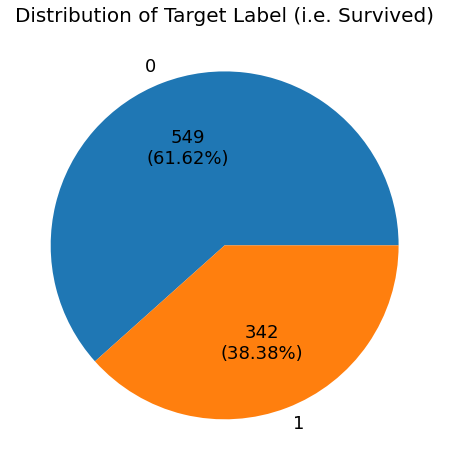

In [5]:
# check whether the data set is balanced

def auto_fmt (pct_value):
    return '{:.0f}\n({:.2f}%)'.format(df_train['Survived'].value_counts().sum()*pct_value/100,pct_value) 

df_survived_count = df_train['Survived'].value_counts().rename_axis('Survived').reset_index(name='Counts')

fig = plt.gcf()
fig.set_size_inches(8,8)
plt.pie(x=df_survived_count['Counts'], labels=df_survived_count['Survived'], autopct=auto_fmt, textprops={'fontsize': 18})
plt.title('Distribution of Target Label (i.e. Survived)',  fontsize = 20)


<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: the distribution of target feature between survived and non-survived classes is not in equal proportion.  However, it is still in a acceptable proportion.  There is no oversampling for this data set. 
</div>


## 3.2. Remove the Data Columns with Unique Identifiers or with Many Unique Values
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Objective: Features in predictive model are used to estimate an asscoiated likelihood of a target (i.e. survived).  In other words, features shall have relevance to the target label.  If the features are unique identifiers or with many unique values, using them as features in predictve model can result in overfitting and reduced model performance.
</div>

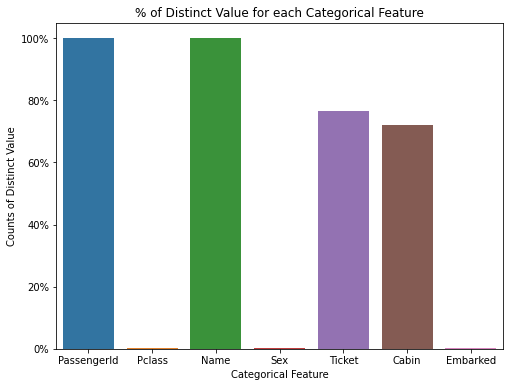

In [6]:
# To count no. of distinct values for each columns.

categorical_st = ['PassengerId', 'Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

df_distinct_counts = df_train[categorical_st].nunique()/df_train[categorical_st].count()
df_distinct_counts = df_distinct_counts.rename_axis('Feature').reset_index(name='Count')

# Use the bar chart to display % of distinct values for each categorical feature

# set the size of the chart
plt.figure(figsize=(8, 6))

# create a bar chart using Seaborn
sns.barplot(x='Feature', y='Count', data=df_distinct_counts)

# add x and y axes with labels
plt.xlabel('Categorical Feature')
plt.ylabel('Counts of Distinct Value')
plt.title('% of Distinct Value for each Categorical Feature')

# create a function to format the y-axis as percentages
def to_percent(y, position):
    return '{:.0%}'.format(y)

# set the y-axis ticks as percentages
formatter = FuncFormatter(to_percent)
plt.gca().yaxis.set_major_formatter(formatter)

# display the chart
plt.show()

<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: From the bar chart above, PassengerId, Name, Ticket and Cabin are likely to be either unique identifier or features with many unique values.  Since these types of features may cause overfitting for predictive models, they are dropped out.
</div>


<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To drop out the aforementioned categorical features
</div>

In [7]:
# The list of categorical features to be removed due to the nature of unique identifiers
drop_out_lst = ['PassengerId', 'Name', 'Ticket', 'Cabin']

df_train.drop(drop_out_lst, axis=1, inplace=True)

# to check if the columns have been removed from the dataframe
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


## 3.2. Missing Value Handling / Replacement
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Objective: to check if the data has missing value. If it is the case, we will do pre-processing for missing value replacement, e.g. replace null with mode for categorical variables and with mean / median for numerical variables
</div>


In [8]:
df_null_value = df_train.isnull().sum().rename_axis('Feature').reset_index(name='No of Null Value')

# Check if there are features with null value
df_null_value[df_null_value['No of Null Value']>0]

,Feature,No of Null Value
3,Age,177
7,Embarked,2


<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: The numerical feature "age" has null value, and we will replace the null value with Median of the feature.  For the categorical feaure "Embarked", we will replace the null value with Mode of the feature.
</div>

<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To replace the null value
</div>

In [9]:
# The null value of numerical feature "age" is replaced wwith Median
median_age = df_train['Age'].median()
df_train['Age'].fillna(median_age, inplace=True)

# The null value of categorical feature "Embarked" is replace with Mode
mode_embarked = df_train['Embarked'].mode()[0]        
df_train['Embarked'].fillna(mode_embarked, inplace=True)

# check again if there are features with null values
df_null_value = df_train.isnull().sum().rename_axis('Feature').reset_index(name='No of Null Value')

# Check if there are features with null value
df_null_value[df_null_value['No of Null Value']>0]

,Feature,No of Null Value


<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: There are no null value after the null value replacement.
</div>

## 3.3. Outlier Analysis
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Objective: Outlier analysis is the process of identifying abnormal or extreme observations in a data set. Since outlier causes distribution to have skew distribution, and decision boundary of a model may be skewed to long-tail side, causing inappropriate decision from models. 
</div>


<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To check for types of features for those with numbers as feature values
</div>

In [10]:
# List of features with 
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: Pclass, Age, SibSp, Parch and Fare are numbers
</div>

<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To check for types of features for those with numbers as feature values
</div>

In [11]:
# List of array for numerical features
num_lst = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

for col in num_lst:
    df_num_feature = df_train[col].value_counts().rename_axis('Numerical Feature').reset_index(name='Count')
    print('No of Distinct Value for Feature {} : {}'.format(col, df_num_feature['Numerical Feature'].nunique()))
    

No of Distinct Value for Feature Pclass : 3
No of Distinct Value for Feature Age : 88
No of Distinct Value for Feature SibSp : 7
No of Distinct Value for Feature Parch : 7
No of Distinct Value for Feature Fare : 248


<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: Age and Fare are numerical features, while Pclass, SibSp and Parch are categorical features. 
</div>

<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Boxplot and Histogram are used for outlier anlaysis.
</div>

<AxesSubplot:xlabel='Fare', ylabel='Count'>

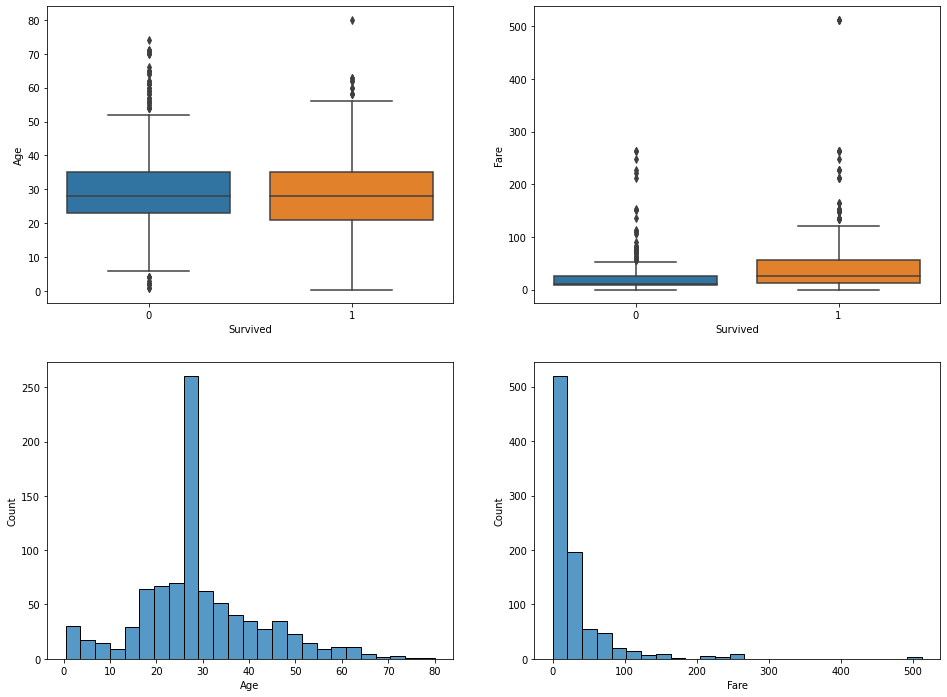

In [12]:
# boxplot and histrogram for numercial features
fig, ax = plt.subplots(2, 2, figsize=(16,12))

sns.boxplot(x="Survived",y="Age",data=df_train, ax=ax[0][0])
sns.boxplot(x="Survived",y="Fare",data=df_train, ax=ax[0][1])
sns.histplot(data=df_train, x =df_train['Age'], bins=25, ax=ax[1][0])
sns.histplot(data=df_train, x =df_train['Fare'], bins=25, ax=ax[1][1])


<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: There are outliers for the numerical features of Age and Fare.  The distribution is skewness to the right long-tail. 
</div>

<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To remove outliers by <b>IRQ method</b> - IQR method is used to identify outliers to set up a boundary outside of Q1 and Q3. Any values that fall outside of the boundary are considered outliers. 
</div>



In [13]:
numerical = ['Age', 'Fare']
IRQ_dict = {}

for col in numerical:
        p75 = df_train[df_train[col] > 0][col].quantile(0.75)
        p25 = df_train[df_train[col] > 0][col].quantile(0.25)
        iqr = p75 - p25
        upper_limit = p75 + (1.5 * iqr)
        IRQ_dict[col] = upper_limit
        print('===={} with Upper Limit {:6.1f}, P75 {:6.1f}, P25 {:6.1f}, {} Outlier Records ========'.format(col, upper_limit, p75, p25, df_train[df_train[col] > upper_limit]['Survived'].count()))
        df_train[col] = np.where (df_train[col] > upper_limit, upper_limit, df_train[col])

====Age with Upper Limit   54.5, P75   35.0, P25   22.0, 42 Outlier Records ========
====Fare with Upper Limit   66.3, P75   31.3, P25    7.9, 116 Outlier Records ========


<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To update the Boxplot and Histogram to check for outlier and distribution again.
</div>



<AxesSubplot:xlabel='Fare', ylabel='Count'>

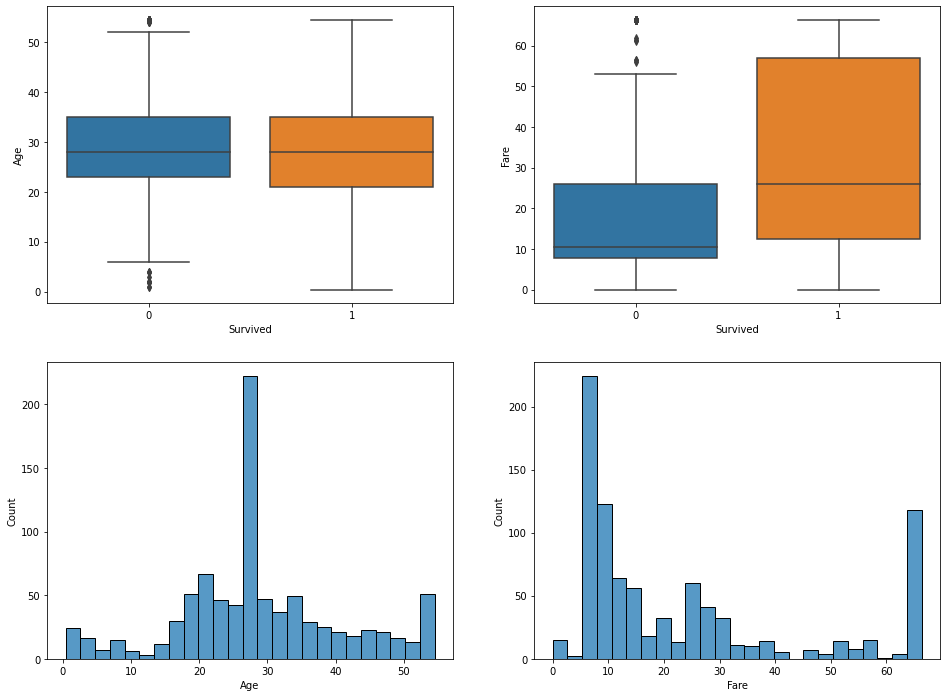

In [14]:
# boxplot and histrogram for numercial features
fig, ax = plt.subplots(2, 2, figsize=(16,12))

sns.boxplot(x="Survived",y="Age",data=df_train, ax=ax[0][0])
sns.boxplot(x="Survived",y="Fare",data=df_train, ax=ax[0][1])
sns.histplot(data=df_train, x =df_train['Age'], bins=25, ax=ax[1][0])
sns.histplot(data=df_train, x =df_train['Fare'], bins=25, ax=ax[1][1])

<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: With the handling of outliers, the distribution of Age and Fare looks rational now.. 
</div>

# 4. Data Standardization and Encoding

<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Objective: Data standardization is to pull all numerical variables into the same scale so that the discriminative power of features with high ranged value cannot dominate to the importance of target  due to high absolute value of features.  Data encoding is a process to convert categorical features into numerical values so that the distance between values in categorical features can be measured. 
</div>

## 4.1. Numerical Features
<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To standardize the numerical variables with the use of Robust Scaler.  The choice of Robust Scaler over Standard Scaler is  the capability to handle outliers. </div>

In [15]:
scaler = RobustScaler()
encoder_num = scaler.fit_transform(df_train[numerical])
encoded_num = pd.DataFrame(encoder_num, columns = numerical)
encoded_num.shape
print(encoded_num.head(5))

        Age      Fare
0 -0.461538 -0.312011
1  0.769231  2.245418
2 -0.153846 -0.282777
3  0.538462  1.673732
4  0.538462 -0.277363


## 4.2 Categorical Features
<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
We used CatBoost encoder to encode categorical features into numbers. A CatBoost encoder is similar to target encoding, but also involves an ordering principle in order to overcome this problem of target leakage. It uses the principle similar to the time series data validation. The values of target statistic rely on the observed history, i.e, target probability for the current feature is calculated only from the rows (observations) before it.
</div>

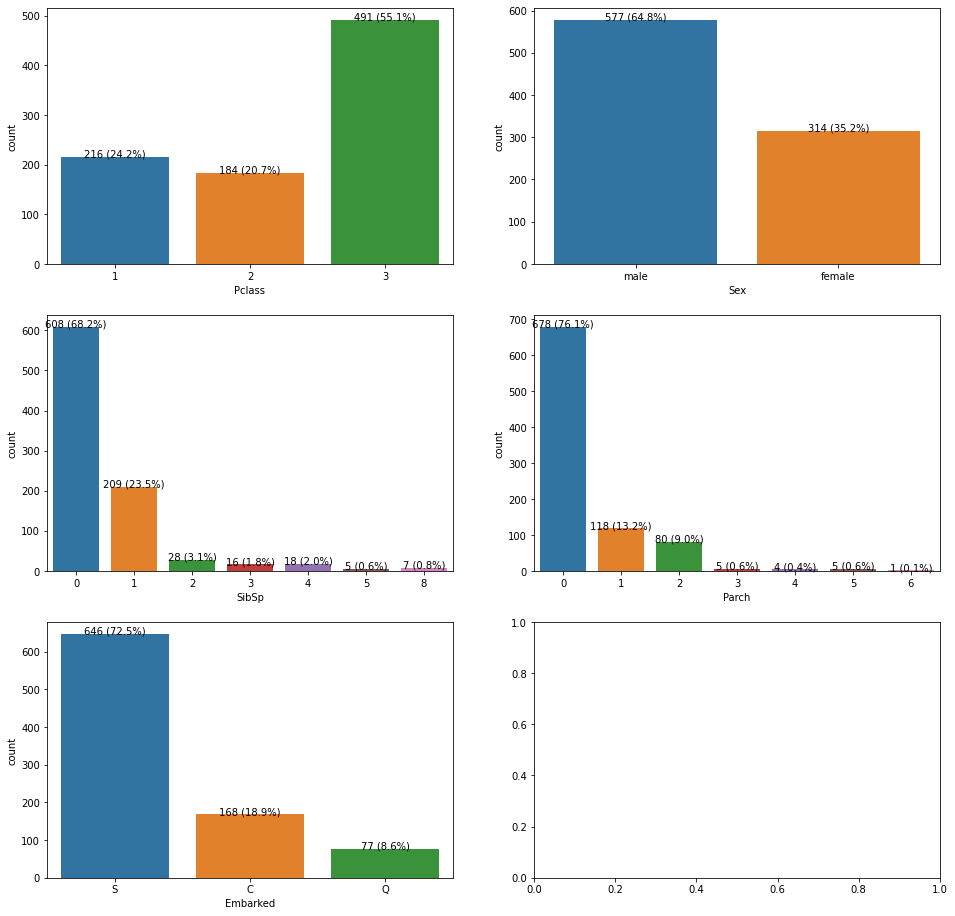

In [16]:
categorical = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

fig, ax = plt.subplots (3, 2, figsize=(16, 16)) 
ax_rst = []

for i in range(len(categorical)):
    axs = sns.countplot(data=df_train, x =df_train[categorical[i]], ax=ax[int(i/2),i % 2])
    ax_rst.append(axs)
    total = df_train[categorical[i]].value_counts().sum()
    for p in axs.patches:
        value_pct = '{:.0f} ({:.1f}%)'.format(p.get_height(), 100 * p.get_height()/total)
        x = p.get_x() + p.get_width()/2
        y = p.get_height()
        axs.annotate(value_pct, (x, y),ha='center')    

In [17]:
CATBoostENCODE = encoders.CatBoostEncoder()

# Cast teh Pclass from integer to string so that we can apply the categorical encoding later
df_train['Pclass'] = df_train['Pclass'].astype(str)
df_train['SibSp'] = df_train['SibSp'].astype(str)
df_train['Parch'] = df_train['Parch'].astype(str)

df_target = df_train['Survived'].astype(str)

# Use CatBoost to encode the categorical values
encoder_cat = CATBoostENCODE.fit_transform(df_train[categorical], df_target)
encoded_cat = pd.DataFrame(encoder_cat)
print(encoded_cat.head(10))

     Pclass       Sex     SibSp     Parch  Embarked
0  0.383838  0.383838  0.383838  0.383838  0.383838
1  0.383838  0.383838  0.191919  0.191919  0.383838
2  0.191919  0.691919  0.383838  0.461279  0.191919
3  0.691919  0.794613  0.461279  0.595960  0.461279
4  0.461279  0.191919  0.691919  0.676768  0.595960
5  0.345960  0.127946  0.461279  0.563973  0.383838
6  0.794613  0.095960  0.345960  0.483405  0.476768
7  0.276768  0.076768  0.383838  0.383838  0.397306
8  0.230640  0.845960  0.276768  0.383838  0.340548
9  0.383838  0.876768  0.595960  0.422980  0.691919


# 5. Model Preparation and Oversampling

<div style=" background-color:#0A1172;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To prepare the data for model training
</div>

In [18]:
df_model_data = df_train.copy()
df_model_data.drop(numerical, axis = 1, inplace=True)
df_model_data.drop(categorical, axis = 1, inplace=True)
df_model_data = pd.concat([df_model_data, encoded_num, encoded_cat], axis=1)
df_model_data.head(5)

,Survived,Age,Fare,Pclass,Sex,SibSp,Parch,Embarked
0,0,-0.461538,-0.312011,0.383838,0.383838,0.383838,0.383838,0.383838
1,1,0.769231,2.245418,0.383838,0.383838,0.191919,0.191919,0.383838
2,1,-0.153846,-0.282777,0.191919,0.691919,0.383838,0.461279,0.191919
3,1,0.538462,1.673732,0.691919,0.794613,0.461279,0.595960,0.461279
4,0,0.538462,-0.277363,0.461279,0.191919,0.691919,0.676768,0.595960


In [19]:
Y = df_model_data.iloc[:,0:1]
X = df_model_data.iloc[:,1:]
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.3)


# 6. Model - Random Forest
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Random Forest is a supervised machine learning algorithm that is used for both classification and regression tasks. It is an ensemble learning method that combines multiple decision trees to improve the accuracy and stability of the predictions.
<br><br>
The Random Forest algorithm works by building multiple decision trees on randomly selected subsets of the training data and features. Each tree is constructed by recursively splitting the data into smaller subsets based on the most informative feature at each node, until a stopping criterion is met. The final prediction is made by aggregating the predictions of all the individual trees, either by majority voting in classification tasks or by taking the average in regression tasks.
</div>



## 6.1 Hyperparameter Tuning
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Hyperparameter tuning, also known as hyperparameter optimization, is the process of searching for the best combination of hyperparameters that maximize the performance of a machine learning model on a given task. It is important because different values of hyperparameters can have a significant impact on the performance of the model, and there is no way to determine the best hyperparameters analytically. 
<br><br>
Hyperparameters are parameters that are not learned from the data, but rather set before the training process begins. They define the structure and behavior of the machine learning algorithm, such as the number of hidden layers in a neural network, the learning rate of the optimizer, or the regularization strength.
</div>


In [20]:
# parameter list
p_cv = 5
p_score = 'accuracy'
n_iter_search = 250

In [21]:
# # Maximum number of depth in each tree:
# max_depth = [5,7,10, 12, 15]
# # Minimum number of samples to consider at each leaf node:
# min_samples_leaf = [10,12,15, 20, 25]## Decision Tree
# # Minimum number of samples to consider to split a node:
# min_samples_split = [10,12,15, 20, 25]
# # No. of estimators
# estimators = [500, 750, 1000]

# Hyperparameters
forest_params_grid = {
    "max_depth": sp_randint(5, 10),
#     "max_features": sp_randint(5, 25),
    "min_samples_split": sp_randint(3, 5),
    "min_samples_leaf": sp_randint(3, 5),
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"]
}

In [22]:
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

cv = model_selection.StratifiedKFold(n_splits=p_cv, random_state=5463, shuffle=True)

model = RandomizedSearchCV(clf, param_distributions=forest_params_grid,
                                   n_iter=n_iter_search, cv=p_cv, verbose=1, scoring=p_score)

In [23]:
model.fit(X_train, Y_train.values.ravel())
print(model.best_params_)
print(model.best_estimator_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 1250 out of 1250 | elapsed:  6.4min finished


{'bootstrap': False, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 4}
RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=7,
                       min_samples_leaf=3, min_samples_split=4, n_jobs=-1)


Scoring Metrics for Random Forest (Validation)
Balanced Accuracy Score = 0.7855390008764243
Accuracy Score = 0.7947761194029851
Precision Score = 0.7358490566037735
F1 Score = 0.7393364928909951
Recall Score = 0.7428571428571429
ROC AUC Score = 0.7855390008764241
Confusion Matrix
[[135  28]
 [ 27  78]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       163
           1       0.74      0.74      0.74       105

    accuracy                           0.79       268
   macro avg       0.78      0.79      0.79       268
weighted avg       0.80      0.79      0.79       268

Scoring Metrics for Random Forest (Training)
Balanced Accuracy Score = 0.9268271353927549
Accuracy Score = 0.9406099518459069
Precision Score = 0.9716981132075472
F1 Score = 0.9175946547884187
Recall Score = 0.869198312236287
ROC AUC Score = 0.9268271353927549
Confusion Matrix
[[380   6]
 [ 31 206]]
              precision    recall  f1-score   support

           0 

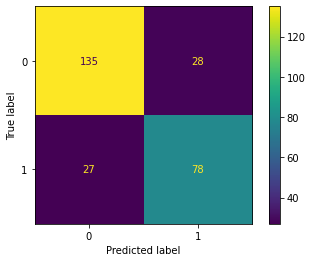

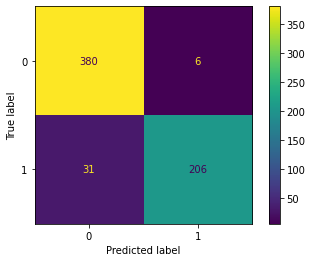

In [24]:
predicted_test = pd.DataFrame(model.predict(X_test))
predicted_train = pd.DataFrame(model.predict(X_train))
print('=============================================')
print('Scoring Metrics for Random Forest (Validation)')
print('=============================================')
print('Balanced Accuracy Score = {}'.format(metrics.balanced_accuracy_score(Y_test, predicted_test)))
print('Accuracy Score = {}'.format(metrics.accuracy_score(Y_test, predicted_test)))
print('Precision Score = {}'.format(metrics.precision_score(Y_test, predicted_test)))
print('F1 Score = {}'.format(metrics.f1_score(Y_test, predicted_test, labels=['0','1'])))
print('Recall Score = {}'.format(metrics.recall_score(Y_test, predicted_test, labels=['0','1'])))
print('ROC AUC Score = {}'.format(metrics.roc_auc_score(Y_test, predicted_test, labels=['0','1'])))
print('Confusion Matrix')
print('==================')
print(metrics.confusion_matrix(Y_test, predicted_test))
print('==================')
print(metrics.classification_report(Y_test, predicted_test, target_names=['0','1']))
metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(Y_test, predicted_test)).plot()


print('=============================================')
print('Scoring Metrics for Random Forest (Training)')
print('=============================================')
print('Balanced Accuracy Score = {}'.format(metrics.balanced_accuracy_score(Y_train, predicted_train)))
print('Accuracy Score = {}'.format(metrics.accuracy_score(Y_train, predicted_train)))
print('Precision Score = {}'.format(metrics.precision_score(Y_train, predicted_train)))
print('F1 Score = {}'.format(metrics.f1_score(Y_train, predicted_train)))
print('Recall Score = {}'.format(metrics.recall_score(Y_train, predicted_train, labels=['0','1'])))
print('ROC AUC Score = {}'.format(metrics.roc_auc_score(Y_train, predicted_train, labels=['0','1'])))
print('Confusion Matrix')
print('==================')
print(metrics.confusion_matrix(Y_train, predicted_train))
print('==================')
print(metrics.classification_report(Y_train, predicted_train, target_names=['0','1']))
metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(Y_train, predicted_train)).plot()

# 7. Data Submission

In [25]:
# Read the data
df_test = pd.read_csv('../input/titanic/test.csv')
df_id = df_test.iloc[:,0:1]

# Delete columns with unique identifiers
df_test.drop(drop_out_lst, axis = 1, inplace=True)

# Replace null age with median 
df_test['Age'].fillna(median_age, inplace=True)
df_test['Embarked'].fillna(mode_embarked, inplace=True)
df_test['Fare'].fillna(df_test['Fare'].median(), inplace=True)

# Outlier handling
df_test['Age'] = np.where (df_test['Age'] > IRQ_dict['Age'], IRQ_dict['Age'], df_test['Age'])
df_test['Fare'] = np.where (df_test['Fare'] > IRQ_dict['Fare'], IRQ_dict['Fare'], df_test['Fare'])

# Data Scaler
test_encoder_num = scaler.transform(df_test[numerical])
test_encoded_num = pd.DataFrame(test_encoder_num, columns = numerical)
test_encoded_num.shape
print(test_encoded_num.shape)

# Data Encoder
df_test['Pclass'] = df_test['Pclass'].astype(str)
df_test['SibSp'] = df_test['SibSp'].astype(str)
df_test['Parch'] = df_test['Parch'].astype(str)
test_encoder_cat = CATBoostENCODE.transform(df_test[categorical])
test_encoded_cat = pd.DataFrame(test_encoder_cat, columns=categorical)
print(test_encoded_cat.shape)

# Prepare the dataset
# df_test.drop(numerical, axis = 1, inplace=True)
# df_test.drop(categorical, axis = 1, inplace=True)
df_test = pd.concat([test_encoded_num, test_encoded_cat], axis=1)
df_test.head(5)


(418, 2)
(418, 5)


,Age,Fare,Pclass,Sex,SibSp,Parch,Embarked
0,0.500000,-0.286926,0.242650,0.189245,0.345458,0.343717,0.389536
1,1.461538,-0.322838,0.242650,0.740901,0.535161,0.343717,0.339079
2,2.038462,-0.206444,0.472345,0.189245,0.345458,0.343717,0.389536
3,-0.076923,-0.250836,0.242650,0.189245,0.345458,0.343717,0.339079
4,-0.461538,-0.093839,0.242650,0.740901,0.535161,0.549444,0.339079


In [26]:
# Prediction
p_model = model.predict(df_test)
df_rst = pd.concat([df_id, pd.DataFrame(p_model, columns = ['Survived'])], axis = 1)
df_rst.to_csv("submission.csv",index=False)
print('Done!')

Done!


### Thanks for your time to read my notebook.  If you like my work, please give me an "upvote" as appreciation.  Happy Kaggling together.  